In [1]:
# Setup imports for the notebook (ensures pd is defined)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


In [2]:
# Prefer real CSV if available; fallback to synthetic
from pathlib import Path
DATA_CSV = Path.cwd() / 'data' / 'sleep.csv'

if DATA_CSV.exists():
    print('Loading dataset from', DATA_CSV)
    df = pd.read_csv(DATA_CSV)
    # Normalize common textual fields
    if 'gender' in df.columns and df['gender'].dtype == object:
        df['gender'] = df['gender'].str.lower().map({'male':1,'m':1,'female':0,'f':0}).fillna(0).astype(int)
    if 'work_type' in df.columns and df['work_type'].dtype == object:
        df['work_type'] = df['work_type'].str.lower().map({'sedentary':0,'light':1,'moderate':2,'heavy':3}).fillna(0).astype(int)
    if 'label' in df.columns and df['label'].dtype == object:
        df['label'] = df['label'].str.lower().map({'healthy':0,'insomnia':1,'sleep apnea':2,'sleep_apnea':2}).astype(int)
else:
    print('No CSV found, using synthetic generator to create df')
    from train_model import generate_synthetic_dataset
    df = generate_synthetic_dataset(num_rows=3000, random_state=123)



Loading dataset from C:\Users\user\Sleep\data\sleep.csv


In [3]:
# Sleep Disorder Prediction — Exploratory Data Analysis (EDA)

# This notebook generates/loads data, previews it, shows distributions,
# evaluates the trained model, and visualizes metrics.

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.preprocessing import label_binarize
import joblib

%matplotlib inline
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / 'models'
MODEL_PATH = MODELS_DIR / 'sleep_model.joblib'

print('Base dir:', BASE_DIR)
print('Model path:', MODEL_PATH)



Base dir: C:\Users\user\Sleep
Model path: C:\Users\user\Sleep\models\sleep_model.joblib


In [4]:
# Ensure required variables exist even if cells were run out-of-order
from pathlib import Path
from sklearn.model_selection import train_test_split
import joblib

# 1) Ensure features, split
try:
    X_train, X_test, y_train, y_test
except NameError:
    features = ['age','gender','bmi','sleep_duration','stress_level','physical_activity','heart_rate','systolic_bp','diastolic_bp','work_type']
    X = df[features]
    y = df['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 2) Ensure model is loaded
try:
    model
except NameError:
    MODEL_PATH = Path.cwd() / 'models' / 'sleep_model.joblib'
    if MODEL_PATH.exists():
        model = joblib.load(MODEL_PATH)
    else:
        from sklearn.ensemble import RandomForestClassifier
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

# 3) Ensure predictions
try:
    y_pred
except NameError:
    y_pred = model.predict(X_test)
# Alias for any cell referencing x_pred
x_pred = y_pred


In [5]:
# Load required CSV only; do not fallback to synthetic
from pathlib import Path
DATA_CSV = Path.cwd() / 'data' / 'sleep.csv'

if not DATA_CSV.exists():
    raise FileNotFoundError("Missing data/sleep.csv. Please place your dataset there and re-run.")

df = pd.read_csv(DATA_CSV)
# Normalize common textual fields
if 'gender' in df.columns and df['gender'].dtype == object:
    df['gender'] = df['gender'].str.lower().map({'male':1,'m':1,'female':0,'f':0}).fillna(0).astype(int)
if 'work_type' in df.columns and df['work_type'].dtype == object:
    df['work_type'] = df['work_type'].str.lower().map({'sedentary':0,'light':1,'moderate':2,'heavy':3}).fillna(0).astype(int)
if 'label' in df.columns and df['label'].dtype == object:
    df['label'] = df['label'].str.lower().map({'healthy':0,'insomnia':1,'sleep apnea':2,'sleep_apnea':2}).astype(int)



In [6]:
# Load or generate dataset
try:
    from train_model import generate_synthetic_dataset
    df = generate_synthetic_dataset(num_rows=3000, random_state=123)
    print('Loaded dataset from train_model.py')
except Exception as e:
    print('Fallback generator due to error:', e)
    rng = np.random.default_rng(123)
    n = 3000
    df = pd.DataFrame({
        'age': rng.integers(18, 80, size=n),
        'gender': rng.integers(0, 2, size=n),
        'bmi': rng.normal(26, 4.5, size=n).clip(14, 55),
        'sleep_duration': rng.normal(7, 1.5, size=n).clip(2, 12),
        'stress_level': rng.integers(0, 11, size=n),
        'physical_activity': rng.integers(0, 300, size=n),
        'heart_rate': rng.integers(55, 100, size=n),
        'systolic_bp': rng.integers(100, 160, size=n),
        'diastolic_bp': rng.integers(60, 100, size=n),
        'work_type': rng.integers(0, 4, size=n),
    })
    # Create label using simple rules to mimic training
    risk = (
        (df['sleep_duration'] < 6).astype(int) * 2
        + (df['bmi'] > 30).astype(int)
        + (df['stress_level'] > 6).astype(int)
        + (df['systolic_bp'] > 140).astype(int)
        + (df['heart_rate'] > 90).astype(int)
    )
    df['label'] = np.select(
        [risk <= 1, (risk == 2) | (df['stress_level'] > 7), risk >= 3],
        [0, 1, 2]
    )

print(df.head())
print('\nInfo:')
df.info()


Loaded dataset from train_model.py
   age  gender        bmi  sleep_duration  stress_level  physical_activity  \
0   18       0  27.911531        4.492589             7                 77   
1   60       1  25.083064       10.769740            10                114   
2   54       1  29.183363        7.913740             8                236   
3   21       1  23.117949        7.658559             0                182   
4   74       1  30.123166        6.036318             9                100   

   heart_rate  systolic_bp  diastolic_bp  work_type  label  
0          60          135            73          1      2  
1          95          131            61          0      1  
2          56          113            94          3      0  
3          69          115            87          2      0  
4          96          155            68          0      1  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column     

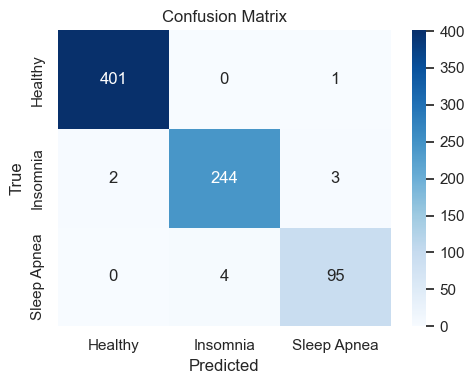

In [7]:
# Confusion matrix visualization (not printed in CLI evaluation)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure y_pred exists; otherwise compute from current model
try:
    y_pred
except NameError:
    y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy','Insomnia','Sleep Apnea'], yticklabels=['Healthy','Insomnia','Sleep Apnea'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


Accuracies:


,Model,Accuracy
2,RandomForest,0.966667
1,SVC_rbf,0.817333
0,LogReg,0.713333


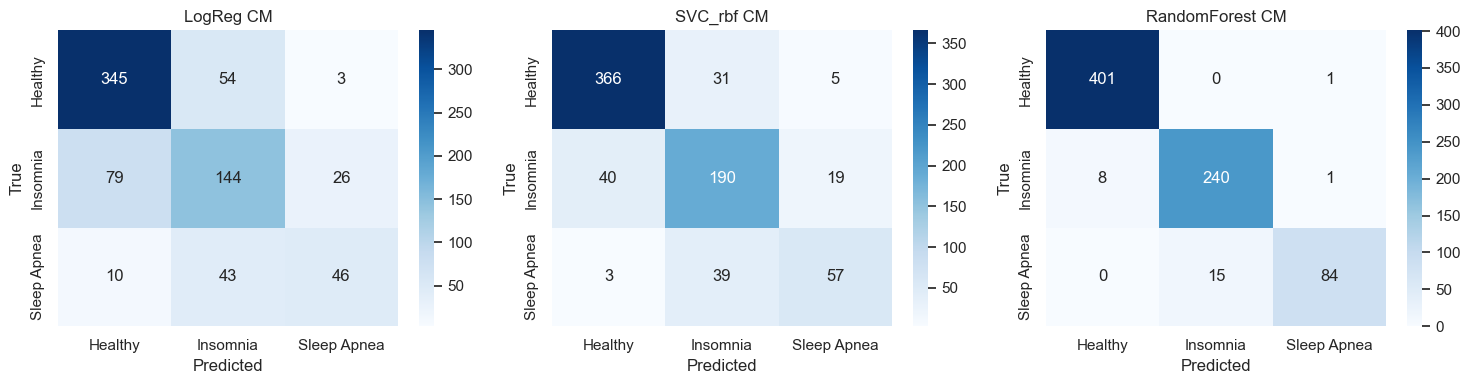

In [9]:
# Compare multiple algorithms and show accuracies + confusion matrices
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

algos = {
    'LogReg': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=400, C=0.8))]),
    'SVC_rbf': Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=0.8, probability=True))]),
    'RandomForest': RandomForestClassifier(n_estimators=150, max_depth=6, min_samples_leaf=8, random_state=42)
}

results = []
conf_mats = {}
for name, model_ in algos.items():
    model_.fit(X_train, y_train)
    yhat = model_.predict(X_test)
    acc = accuracy_score(y_test, yhat)
    results.append({'Model': name, 'Accuracy': acc})
    conf_mats[name] = confusion_matrix(y_test, yhat)

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print('Accuracies:')
display(results_df)

# Plot confusion matrices in a row
k = len(algos)
fig, axes = plt.subplots(1, k, figsize=(5*k, 4))
if k == 1:
    axes = [axes]
for ax, (name, cm) in zip(axes, conf_mats.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Healthy','Insomnia','Sleep Apnea'],
                yticklabels=['Healthy','Insomnia','Sleep Apnea'])
    ax.set_title(f'{name} CM')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()



Describe:


,age,gender,bmi,sleep_duration,stress_level,physical_activity,heart_rate,systolic_bp,diastolic_bp,work_type,label
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000
mean,48.429333,0.487333,26.095856,6.985793,4.940000,150.548667,76.833000,129.509333,79.393333,1.48700,0.592667
std,17.792035,0.499923,4.440770,1.486639,3.181578,86.711094,12.949402,17.180676,11.612676,1.13119,0.697310
min,18.000000,0.000000,14.000000,2.000000,0.000000,0.000000,55.000000,100.000000,60.000000,0.00000,0.000000
25%,33.000000,0.000000,23.006270,5.984018,2.000000,76.000000,65.000000,115.000000,70.000000,0.00000,0.000000
50%,49.000000,0.000000,26.145100,7.011618,5.000000,150.000000,77.000000,130.000000,79.000000,1.00000,0.000000
75%,64.000000,1.000000,29.206088,7.977208,8.000000,225.000000,88.000000,144.000000,90.000000,3.00000,1.000000
max,79.000000,1.000000,40.232937,12.000000,10.000000,299.000000,99.000000,159.000000,99.000000,3.00000,2.000000


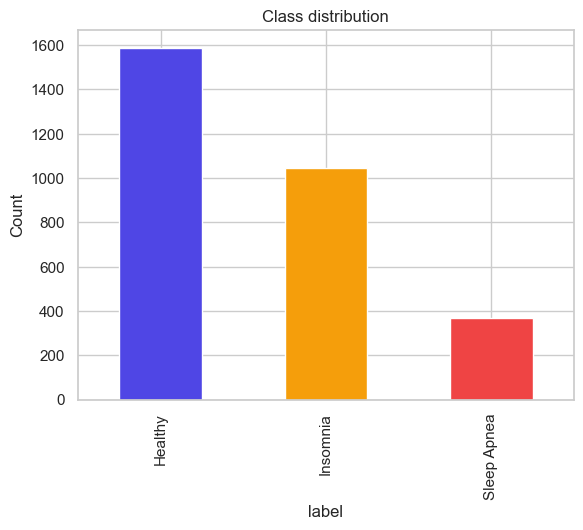

In [10]:
# Basic stats
print('\nDescribe:')
display(df.describe(include='all'))

# Class balance
class_names = ['Healthy','Insomnia','Sleep Apnea']
ax = (df['label']
      .map({0:'Healthy',1:'Insomnia',2:'Sleep Apnea'})
      .value_counts()
      .reindex(class_names)
      .plot(kind='bar', color=['#4f46e5','#f59e0b','#ef4444']))
ax.set_title('Class distribution')
ax.set_ylabel('Count')
plt.show()



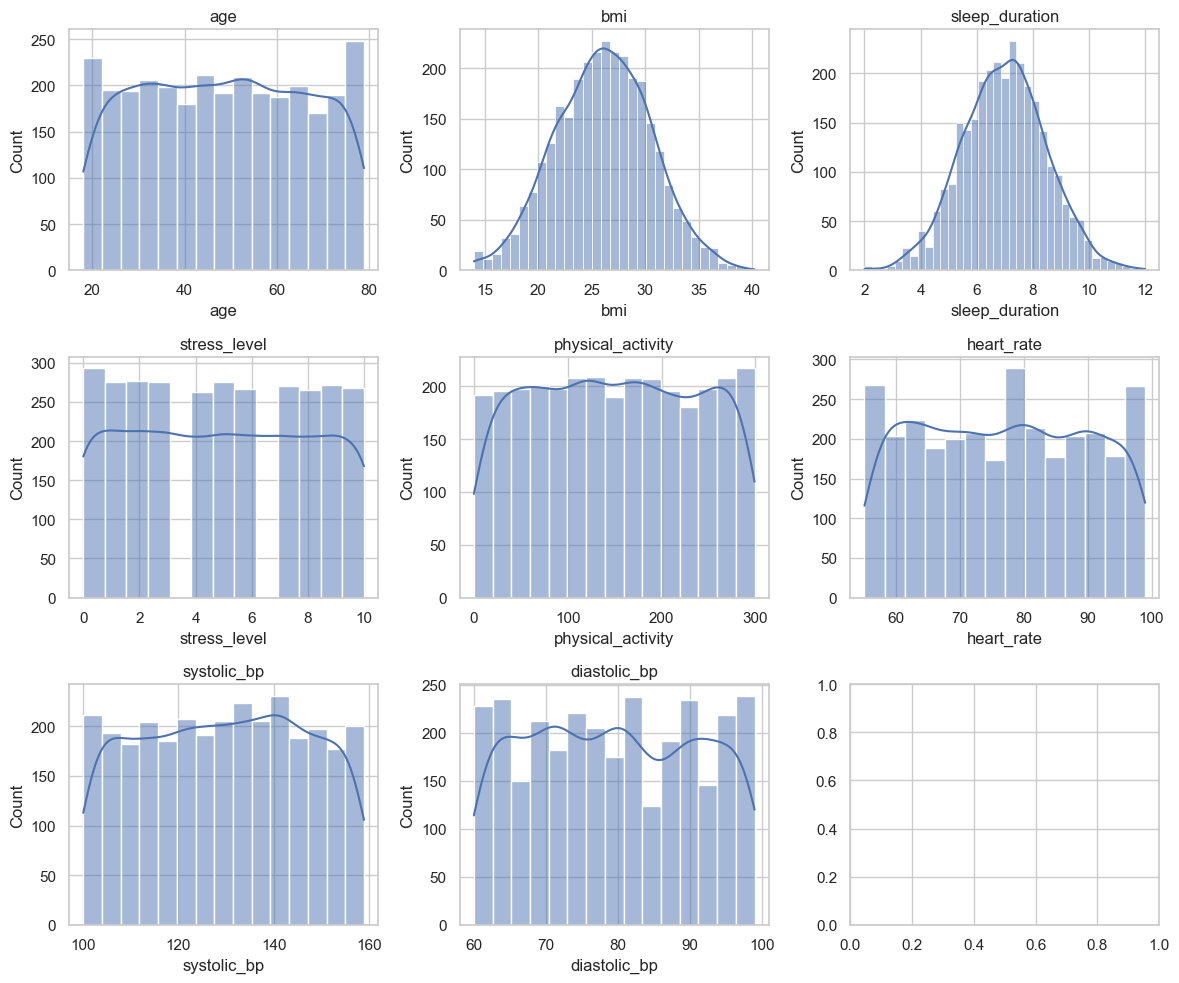

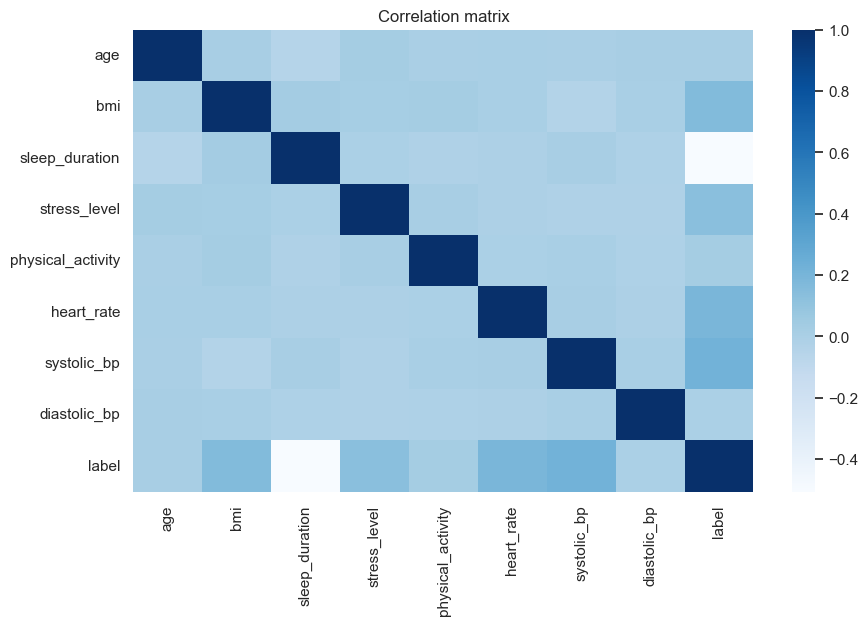

In [11]:
# Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
num_cols = ['age','bmi','sleep_duration','stress_level','physical_activity','heart_rate','systolic_bp','diastolic_bp']
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols + ['label']].corr(), annot=False, cmap='Blues')
plt.title('Correlation matrix')
plt.show()



In [12]:
# Train/test split and model load
features = ['age','gender','bmi','sleep_duration','stress_level','physical_activity','heart_rate','systolic_bp','diastolic_bp','work_type']
X = df[features]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

if not MODEL_PATH.exists():
    print('Model not found, training a quick RandomForest for evaluation...')
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced_subsample')
    model.fit(X_train, y_train)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, MODEL_PATH)
else:
    model = joblib.load(MODEL_PATH)

print('Model loaded:', type(model))



Model loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


Accuracy: 0.9760

Classification report:
              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.99       397
    Insomnia       0.97      0.96      0.97       261
 Sleep Apnea       0.97      0.96      0.96        92

    accuracy                           0.98       750
   macro avg       0.97      0.97      0.97       750
weighted avg       0.98      0.98      0.98       750



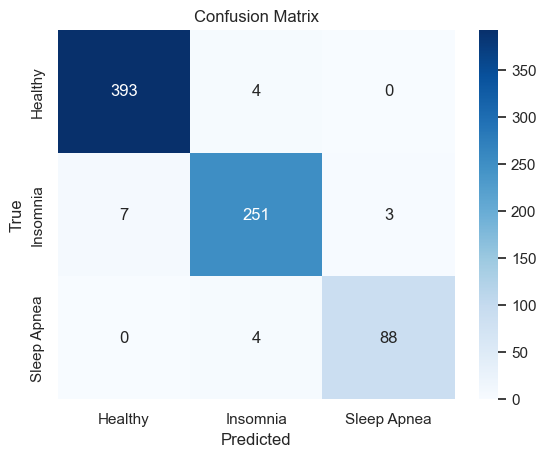

ROC-AUC (macro, OVR): 0.9985


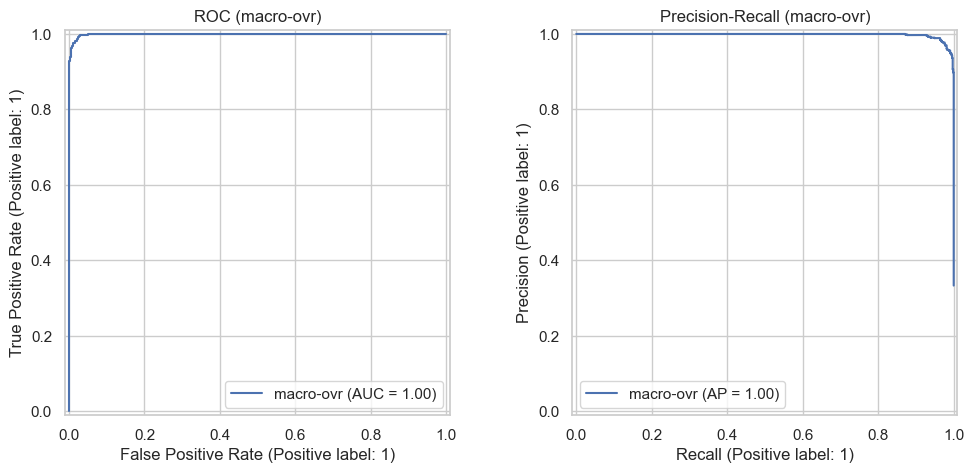

In [13]:
# Metrics
from sklearn.metrics import precision_recall_fscore_support

y_pred = model.predict(X_test)
y_proba = None
try:
    y_proba = model.predict_proba(X_test)
except Exception:
    pass

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Healthy','Insomnia','Sleep Apnea']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy','Insomnia','Sleep Apnea'], yticklabels=['Healthy','Insomnia','Sleep Apnea'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

if y_proba is not None:
    # Macro ROC-AUC (one-vs-rest)
    y_bin = label_binarize(y_test, classes=[0,1,2])
    auc = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
    print(f'ROC-AUC (macro, OVR): {auc:.4f}')
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    RocCurveDisplay.from_predictions(y_bin.ravel(), y_proba.ravel(), name='macro-ovr', ax=ax[0])
    ax[0].set_title('ROC (macro-ovr)')
    PrecisionRecallDisplay.from_predictions(y_bin.ravel(), y_proba.ravel(), name='macro-ovr', ax=ax[1])
    ax[1].set_title('Precision-Recall (macro-ovr)')
    plt.show()
